In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cmocean
from flow import sample_images
# jax is causing memory leaks for me
# from transforms_jax import radon
from transforms import radon
from utils import load_checkpoint_multiflow_v1
from torchdiffeq import odeint
import time
from torch import optim
from torchmetrics import CatMetric
from unet import Unet

/home/johnma/d-flow/venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [2]:
torch.set_float32_matmul_precision('high')
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cuda.enable_flash_sdp(True)
torch.backends.cuda.enable_mem_efficient_sdp(True)
torch.backends.cuda.enable_math_sdp(True)


In [3]:

%%capture
im_size = 128
problem = "shepp-logan"
n_sub = 2
n_full = 24
checkpoint_step = 27750
run_prefix = f'{n_sub}-{n_full}-{im_size}x{im_size}'
full_checkpoint_path = f'problems/multiflow-v1//{problem}/{run_prefix}/checkpoints/full_{n_full}/ckp_{checkpoint_step}.tar'
sub_checkpoint_path = f'problems/multiflow-v1/{problem}/{run_prefix}/checkpoints/sub_{n_sub}/ckp_{checkpoint_step}.tar'
media_checkpoint_path = f'problems/multiflow-v1/{problem}/{run_prefix}/checkpoints/media/ckp_{checkpoint_step}.tar'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# match the number of channels to your model
full_meas_model = Unet(ch=32, ch_mul=[1, 2], att_channels=[0, 1]).to(device)
sub_meas_model = Unet(ch=32, ch_mul=[1, 2], att_channels=[0, 1]).to(device)
media_model = Unet(ch=32).to(device)

_, _, full_meas_model, _, _, A_full = load_checkpoint_multiflow_v1(model=full_meas_model, path=full_checkpoint_path)
full_meas_model.eval()
_, _, sub_meas_model, _, _, A_sub = load_checkpoint_multiflow_v1(model=sub_meas_model, path=sub_checkpoint_path)
sub_meas_model.eval()
_, _, media_model, _, _, A_media = load_checkpoint_multiflow_v1(model=media_model, path=media_checkpoint_path)
A_full = A_full.clone().to(device)
A_sub = A_sub.clone().to(device)
A_media = A_media.clone().to(device)
media_model.eval()
sub_meas_model.eval()
full_meas_model.eval()

/home/johnma/d-flow/venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


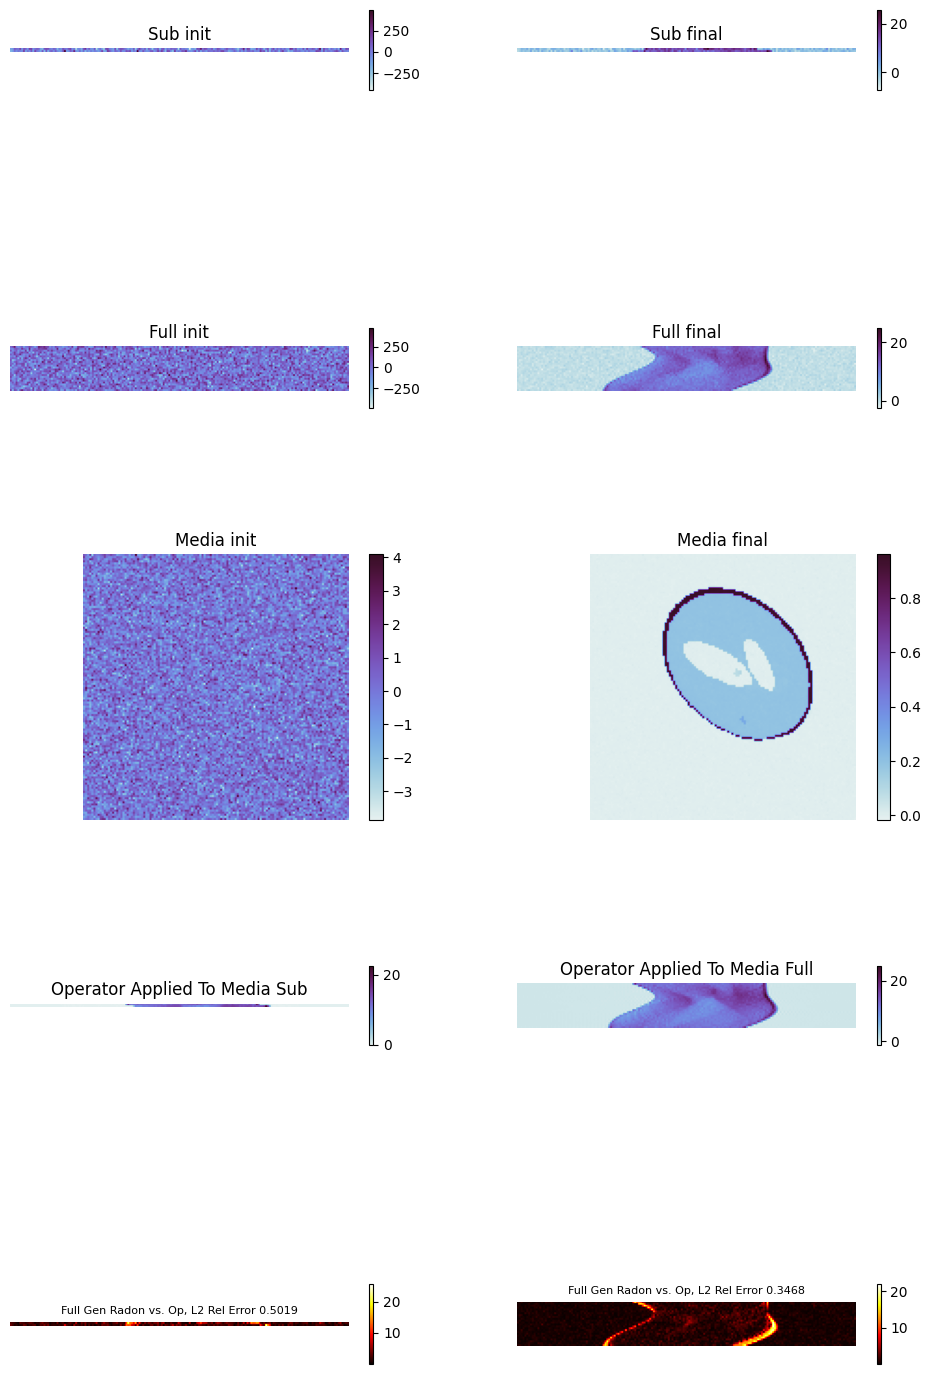

In [4]:
ambient_dim = im_size * im_size

with torch.no_grad():
    x0_amb = torch.randn(1, ambient_dim, device=device)
    x0_sub = torch.matmul(x0_amb, A_sub.T).view(1, 1, n_sub, 182)
    x0_full = torch.matmul(x0_amb, A_full.T).view(1, 1, n_full, 182)
    # x0_media = torch.matmul(x0_amb, A_media.T).view(1, 1, config['image_size'], config['image_size'])
    x0_media = x0_amb.view(1, 1, im_size, im_size)

    t = torch.linspace(0.0, 1.0, 5, device=device)

    sub_samples = odeint(
        func = lambda t, x: sub_meas_model(x, t.expand(x.shape[0])),
        t = t,
        y0 = x0_sub,
        method = 'dopri5',
        atol = 1e-5,
        rtol = 1e-5,
    )[-1].squeeze().cpu()

    full_samples = odeint(
        func = lambda t, x: full_meas_model(x, t.expand(x.shape[0])),
        t = t,
        y0 = x0_full,
        method = 'dopri5',
        atol = 1e-5,
        rtol = 1e-5,
    )[-1].squeeze().cpu()

    media_samples = odeint(
        func = lambda t, x: media_model(x, t.expand(x.shape[0])),
        t = t,
        y0 = x0_media,
        method = 'dopri5',
        atol = 1e-5,
        rtol = 1e-5,
    )[-1].squeeze().cpu()
    fig, axs = plt.subplots(5, 2, figsize=(12, 20))
    im = axs[0, 0].imshow(x0_sub.squeeze().cpu(), cmap=cmocean.cm.dense)
    fig.colorbar(im, ax=axs[0, 0], shrink=0.3)
    axs[0, 0].set_title('Sub init')
    axs[0, 0].axis('off')

    im = axs[0, 1].imshow(sub_samples, cmap=cmocean.cm.dense)
    fig.colorbar(im, ax=axs[0, 1], shrink=0.3)
    axs[0, 1].set_title('Sub final')
    axs[0, 1].axis('off')

    im = axs[1, 0].imshow(x0_full.squeeze().cpu(), cmap=cmocean.cm.dense)
    fig.colorbar(im, ax=axs[1, 0], shrink=0.3)
    axs[1, 0].set_title('Full init')
    axs[1, 0].axis('off')

    im = axs[1, 1].imshow(full_samples, cmap=cmocean.cm.dense)
    fig.colorbar(im, ax=axs[1, 1], shrink=0.3)
    axs[1, 1].set_title('Full final')
    axs[1, 1].axis('off')

    im = axs[2, 0].imshow(x0_media.squeeze().cpu(), cmap=cmocean.cm.dense)
    fig.colorbar(im, ax=axs[2, 0])
    axs[2, 0].set_title('Media init')
    axs[2, 0].axis('off')

    im = axs[2, 1].imshow(media_samples, cmap=cmocean.cm.dense)
    fig.colorbar(im, ax=axs[2, 1])
    axs[2, 1].set_title('Media final')
    axs[2, 1].axis('off')

    # take the media sample and apply radon transform with n_sub and n_full
    from transforms import radon
    sub_radon = radon.radon_transform(media_samples, N=n_sub).cpu()
    full_radon = radon.radon_transform(media_samples, N=n_full).cpu()
    im = axs[3, 0].imshow(sub_radon, cmap=cmocean.cm.dense)
    fig.colorbar(im, ax=axs[3, 0], shrink=0.3)
    axs[3, 0].set_title('Operator Applied To Media Sub')
    axs[3, 0].axis('off')

    im = axs[3, 1].imshow(full_radon, cmap=cmocean.cm.dense)
    fig.colorbar(im, ax=axs[3, 1], shrink=0.3)
    axs[3, 1].set_title('Operator Applied To Media Full')
    axs[3, 1].axis('off')

    # calcuate rel error
    sub_error = torch.norm(sub_radon - sub_samples) / torch.norm(sub_samples)
    full_error = torch.norm(full_radon - full_samples) / torch.norm(full_samples)

    im = axs[4, 0].imshow((sub_radon - sub_samples).abs(), cmap='hot')
    fig.colorbar(im, ax=axs[4, 0], shrink=0.3)
    axs[4, 0].set_title(f'Full Gen Radon vs. Op, L2 Rel Error {sub_error:.4f}', fontsize=8)
    axs[4, 0].axis('off')

    im = axs[4, 1].imshow((full_radon - full_samples).abs(), cmap='hot')
    fig.colorbar(im, ax=axs[4, 1], shrink=0.3)
    axs[4, 1].set_title(f'Full Gen Radon vs. Op, L2 Rel Error {full_error:.4f}', fontsize=8)
    axs[4, 1].axis('off')


    plt.show()

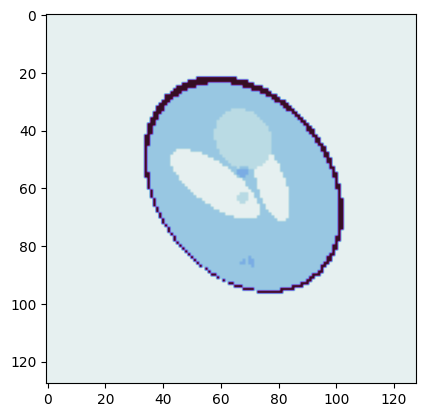

In [4]:
test_data = torch.load(f'data/{problem}-dataset-{im_size}.pt')['test']
gt = test_data[15].to(device)
plt.imshow(gt.cpu().squeeze(), cmap=cmocean.cm.dense)

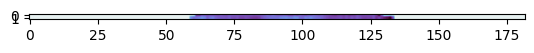

In [6]:
sparse_meas = radon.radon_transform(gt, N=n_sub).to(device)
plt.imshow(sparse_meas.cpu().squeeze(), cmap=cmocean.cm.dense)

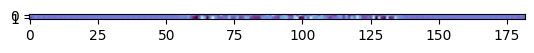

In [7]:
# solve reverse ode for sparse meas
t = torch.linspace(1.0, 0, 5, device=device)
sparse_meas = sparse_meas.view(1, 1, n_sub, 182).to(device)
with torch.no_grad():
    reverse_int = odeint(
        func = lambda t, x: sub_meas_model(x, t.expand(x.shape[0])),
        t = t,
        y0 = sparse_meas,
        method = 'dopri5',
        atol = 1e-5,
        rtol = 1e-5,
    )[-1]
y_0 = sparse_meas + reverse_int

plt.imshow(y_0.cpu().squeeze(), cmap=cmocean.cm.dense)

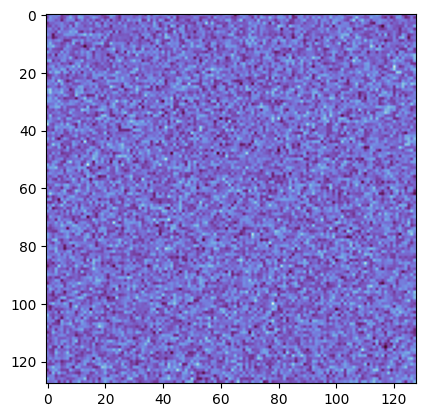

In [8]:
# transport it to ambient dim via pseudoinverse
A_sub_pinv = torch.linalg.pinv(A_sub)
y_0 = y_0.view(n_sub * 182)
y_0_amb = torch.matmul(A_sub_pinv, y_0).view(1, 1, im_size, im_size)
plt.imshow(y_0_amb.cpu().squeeze(), cmap=cmocean.cm.dense)

In [ ]:
# transport it to media space
t = torch.linspace(0, 1, 5, device=device)
media_y_0 = odeint(
                func = lambda t, x: media_model(x, t.expand(x.shape[0])),
                t = t,
                y0 = y_0_amb,
                method = 'rk4',
                atol = 1e-5,
                rtol = 1e-5,
            )[-1].squeeze().cpu()

OutOfMemoryError: CUDA out of memory. Tried to allocate 256.00 MiB. GPU 0 has a total capacity of 47.37 GiB of which 58.75 MiB is free. Process 550523 has 10.71 GiB memory in use. Process 551007 has 10.71 GiB memory in use. Including non-PyTorch memory, this process has 25.87 GiB memory in use. Of the allocated memory 25.15 GiB is allocated by PyTorch, and 177.82 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)